# cosmocnc vs cosmocnc_jax: Full Numerical Comparison

This notebook provides a comprehensive comparison between `cosmocnc` (NumPy reference) and `cosmocnc_jax` (JAX port), verifying that all computed quantities agree to high precision. It covers all the functionality demonstrated in the [cosmocnc tutorial](https://github.com/inigozubeldia/cosmocnc/blob/main/tutorials/cosmocnc_tutorial.ipynb).

**Setup**: Both packages use `classy_sz` as the cosmology tool (same cosmology backend) with `n_points_data_lik=256` and an SO-like simulated catalogue (`SO_sim_0`) with two mass observables:
- **q_so_sim**: tSZ signal-to-noise
- **p_so_sim**: CMB lensing signal-to-noise

**Sections**:
1. Setup & Initialisation + Catalogue verification
2. Halo Mass Function
3. Cluster Abundance (dn/dz, dn/dSNR, N_tot, abundance matrix)
4. Cosmological Quantities (D_A, E_z)
5. Binned Likelihood (theory vs observed counts, by z and SNR)
6. Unbinned Likelihood (from abundance)
7. Unbinned Likelihood (backward convolutional)
8. Stacked Likelihood (stacked CMB lensing observable)
9. Extreme Value Statistics, Goodness of Fit, & Cluster Mass Estimation
10. Parameter Scan ($\sigma_8$ likelihood curves)
11. Summary

In [1]:
# ── Environment setup ──
import os
_N_THREADS = "10"
os.environ["OMP_NUM_THREADS"] = _N_THREADS
os.environ["OPENBLAS_NUM_THREADS"] = _N_THREADS
os.environ["MKL_NUM_THREADS"] = _N_THREADS
os.environ["NUMEXPR_MAX_THREADS"] = _N_THREADS
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ["XLA_FLAGS"] = ""
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
import time
import sys

sys.path = [p for p in sys.path if p not in ('', '.', '/scratch/scratch-izubeldia')]
import cosmocnc
import cosmocnc_jax

print(f"JAX devices: {jax.devices()}")
print(f"Float64 enabled: {jnp.zeros(1).dtype == jnp.float64}")

W0000 00:00:1773179757.198772 2680698 gpu_device.cc:2431] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


defaulting to  /rds-d4/user/iz221/hpc-work/cosmopower/
defaulting to  /scratch/scratch-izubeldia/cosmocnc/cosmocnc/


defaulting to  /rds-d4/user/iz221/hpc-work/cosmopower/
defaulting to  /scratch/scratch-izubeldia/cosmocnc_jax/cosmocnc_jax/


JAX devices: [CudaDevice(id=0)]
Float64 enabled: True


## 1. Setup & Initialisation

We configure both packages with identical parameters. The key settings:
- `n_points_data_lik = 256` (mass grid for backward conv — kept small for future 2D+ convolutions)
- `n_points = 16384` (HMF mass grid)
- `n_z = 100` redshift bins from z=0.01 to z=3
- Both use `classy_sz` cosmology so any differences are purely algorithmic

In [2]:
# ── Shared parameters ──
SCAL_REL = {"corr_lnq_lnp": 0., "bias_sz": 0.8, "dof": 0.}

BASE_PARAMS = {
    "cluster_catalogue": "SO_sim_0",
    "obs_select": "q_so_sim",
    "compute_abundance_matrix": True,
    "number_cores_hmf": 1, "number_cores_abundance": 1,
    "number_cores_data": 1, "number_cores_stacked": 1,
    "parallelise_type": "redshift",
    "obs_select_min": 5., "obs_select_max": 200.,
    "z_min": 0.01, "z_max": 3., "n_z": 100,
    "M_min": 1e13, "M_max": 1e16, "n_points": 16384,
    "n_points_data_lik": 256,
    "sigma_mass_prior": 10, "downsample_hmf_bc": 2,
    "delta_m_with_ref": True, "scalrel_type_deriv": "numerical",
    "cosmo_param_density": "critical", "cosmo_model": "lcdm",
    "hmf_calc": "cnc", "interp_tinker": "linear",
    "likelihood_type": "unbinned",
    "observables": [["q_so_sim"], ["p_so_sim"]],
    "data_lik_from_abundance": False,
    "stacked_likelihood": False,
    "cosmology_tool": "classy_sz",
    "binned_lik_type": "z_and_obs_select",
    "bins_edges_z": np.linspace(0.01, 3., 9),
    "bins_edges_obs_select": np.exp(np.linspace(np.log(5.), np.log(200.), 7)),
}

def setup(pkg, params_override=None):
    """Initialise a cluster_number_counts object."""
    nc = pkg.cluster_number_counts()
    nc.cnc_params.update(dict(BASE_PARAMS))
    if params_override:
        nc.cnc_params.update(params_override)
    nc.scal_rel_params.update(dict(SCAL_REL))
    nc.initialise()
    return nc

timings = {}  # collect all timings

In [3]:
# ── Initialise both packages ──
print("Initialising cosmocnc (NumPy)...")
t0 = time.time()
nc_np = setup(cosmocnc)
timings["init_np"] = time.time() - t0
print(f"  Done in {timings['init_np']:.1f}s")

print("\nInitialising cosmocnc_jax (JAX)...")
t0 = time.time()
nc_jax = setup(cosmocnc_jax)
timings["init_jax"] = time.time() - t0
print(f"  Done in {timings['init_jax']:.1f}s")

Initialising cosmocnc (NumPy)...
Directory /scratch/lxu/class_sz_data_directory does not exist. Falling back to default path.
Defaulting to: /home/cmbagent/class_sz_data_directory


/scratch/scratch-izubeldia/cosmocnc/cosmocnc/cnc.py:71: DeprecationWarning: compute_class_szfast is deprecated. Use initialize_classy_szfast instead.
  self.cosmology = cosmology_model(cosmo_params=self.cosmo_params,
/scratch/scratch-izubeldia/cosmocncenv/lib/python3.12/site-packages/mcfit/mcfit.py:130: UserWarning: use backend='jax' if desired
  warnings.warn("use backend='jax' if desired")


cosmo params {'Om0': 0.315, 'Ob0': 0.04897, 'Ob0h2': 0.022245895720000002, 'Oc0h2': 0.12085104428000001, 'h': 0.674, 'A_s': np.float64(2.0846720158043235e-09), 'n_s': 0.96, 'm_nu': 0.06, 'sigma_8': 0.8110000000000002, 'tau_reio': 0.0544, 'w0': -1.0, 'Onu0': 0.001418083698824921, 'N_eff': 3.046, 'k_cutoff': 100000000.0, 'ps_cutoff': 1}


  Done in 6.4s

Initialising cosmocnc_jax (JAX)...


/scratch/scratch-izubeldia/cosmocnc_jax/cosmocnc_jax/cnc.py:341: DeprecationWarning: compute_class_szfast is deprecated. Use initialize_classy_szfast instead.
  self.cosmology = cosmology_model(cosmo_params=self.cosmo_params,


cosmo params {'Om0': 0.315, 'Ob0': 0.04897, 'Ob0h2': 0.022245895720000002, 'Oc0h2': 0.12085104428000001, 'h': 0.674, 'A_s': np.float64(2.0846720158043235e-09), 'n_s': 0.96, 'm_nu': 0.06, 'sigma_8': 0.8110000000000002, 'tau_reio': 0.0544, 'w0': -1.0, 'Onu0': 0.001418083698824921, 'N_eff': 3.046, 'k_cutoff': 100000000.0, 'ps_cutoff': 1}


  Done in 2.3s


In [4]:
# ── Compute number counts ──
print("Computing number counts (cosmocnc)...")
t0 = time.time()
nc_np.get_number_counts()
timings["nc_np"] = time.time() - t0

print("Computing number counts (cosmocnc_jax)...")
t0 = time.time()
nc_jax.get_number_counts()
timings["nc_jax"] = time.time() - t0

print(f"\n  cosmocnc:     {timings['nc_np']:.2f}s")
print(f"  cosmocnc_jax: {timings['nc_jax']:.2f}s")

Computing number counts (cosmocnc)...


Total clusters: %.5f 15639.631922729868
Computing number counts (cosmocnc_jax)...



  cosmocnc:     0.92s
  cosmocnc_jax: 6.64s


### Catalogue Data Verification

Both packages must load the same cluster catalogue. We verify the cluster redshifts, tSZ SNR ($q$), and CMB lensing SNR ($p$) are identical.

Number of clusters: 15798
Redshift range: [0.0129, 2.3676]
q (tSZ SNR) range: [5.00, 94.86]
p (lensing SNR) range: [-4.12, 4.08]

Catalogue agreement:
  z:  identical = True
  q:  identical = True
  p:  identical = True


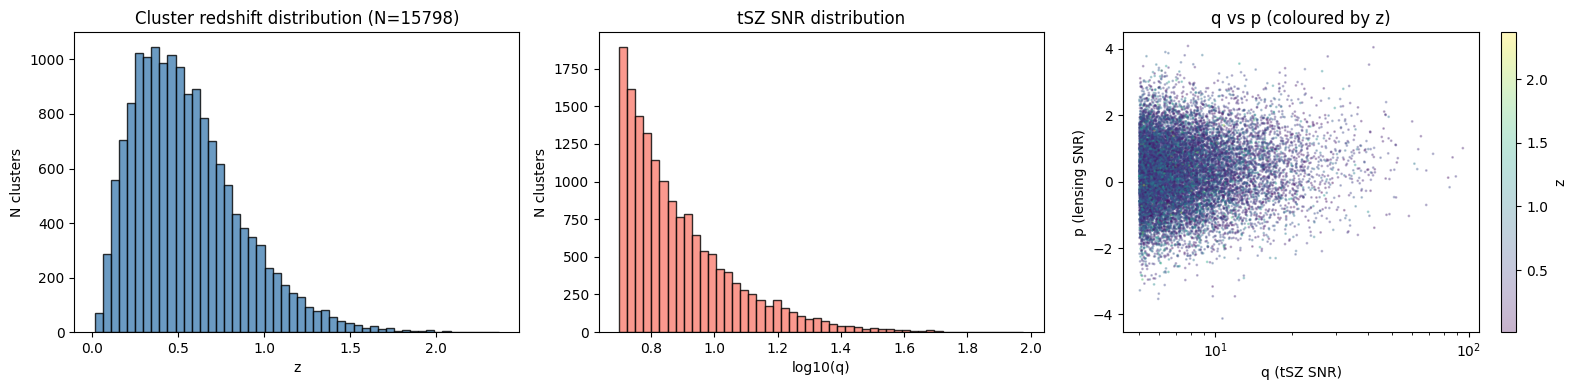

Saved: comparison_catalogue.png


In [5]:
# ── Catalogue data ──
cat_np = nc_np.catalogue
cat_jax = nc_jax.catalogue

z_cat_np = np.asarray(cat_np.catalogue["z"])
z_cat_jax = np.asarray(cat_jax.catalogue["z"])
q_cat_np = np.asarray(cat_np.catalogue["q_so_sim"])
q_cat_jax = np.asarray(cat_jax.catalogue["q_so_sim"])
p_cat_np = np.asarray(cat_np.catalogue["p_so_sim"])
p_cat_jax = np.asarray(cat_jax.catalogue["p_so_sim"])

n_clusters = len(z_cat_np)
print(f"Number of clusters: {n_clusters}")
print(f"Redshift range: [{z_cat_np.min():.4f}, {z_cat_np.max():.4f}]")
print(f"q (tSZ SNR) range: [{q_cat_np.min():.2f}, {q_cat_np.max():.2f}]")
print(f"p (lensing SNR) range: [{p_cat_np.min():.2f}, {p_cat_np.max():.2f}]")

# Verify identical
print(f"\nCatalogue agreement:")
print(f"  z:  identical = {np.array_equal(z_cat_np, z_cat_jax)}")
print(f"  q:  identical = {np.array_equal(q_cat_np, q_cat_jax)}")
print(f"  p:  identical = {np.array_equal(p_cat_np, p_cat_jax)}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.hist(z_cat_np, bins=50, alpha=0.8, color='steelblue', edgecolor='k')
ax.set_xlabel('z'); ax.set_ylabel('N clusters')
ax.set_title(f'Cluster redshift distribution (N={n_clusters})')

ax = axes[1]
ax.hist(np.log10(q_cat_np), bins=50, alpha=0.8, color='salmon', edgecolor='k')
ax.set_xlabel('log10(q)'); ax.set_ylabel('N clusters')
ax.set_title('tSZ SNR distribution')

ax = axes[2]
ax.scatter(q_cat_np, p_cat_np, s=1, alpha=0.3, c=z_cat_np, cmap='viridis')
ax.set_xlabel('q (tSZ SNR)'); ax.set_ylabel('p (lensing SNR)')
ax.set_xscale('log')
cb = plt.colorbar(ax.collections[0], ax=ax, label='z')
ax.set_title('q vs p (coloured by z)')

plt.tight_layout()
plt.savefig('comparison_catalogue.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison_catalogue.png")

## 2. Halo Mass Function

The HMF matrix has shape `(n_z, n_points)` — the differential number density of halos per unit ln(M) at each redshift. This is the foundation for all subsequent calculations.

HMF matrix shape: (100, 16384)
Redshift range: [0.010, 3.000]

HMF agreement (where > 1e-30):
  max  relative diff: 5.82e-13
  mean relative diff: 1.94e-14


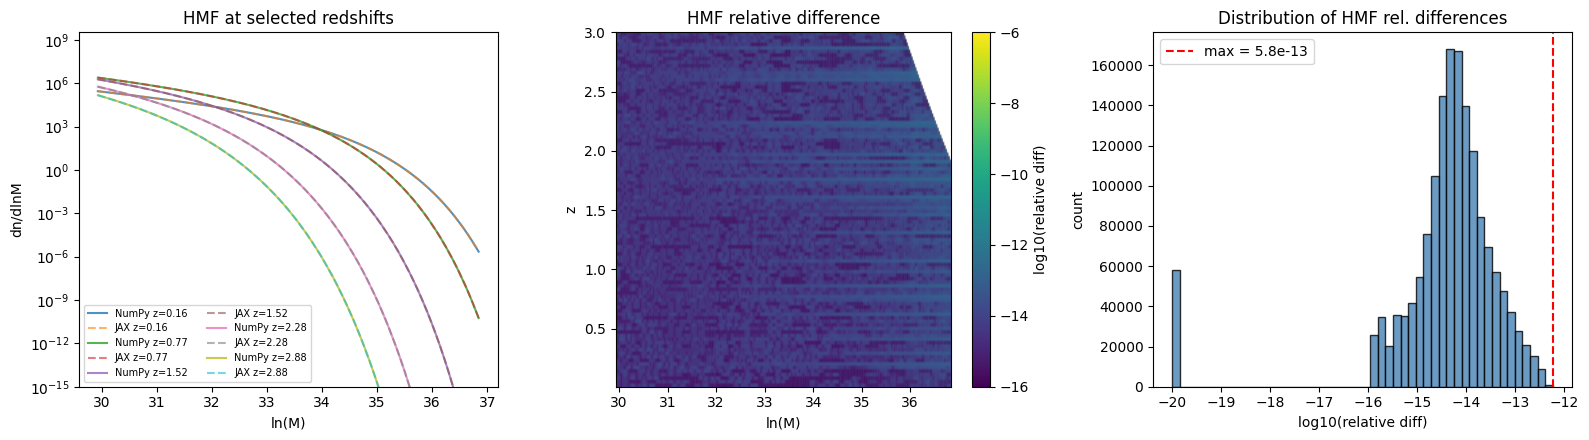

Saved: comparison_hmf.png


In [6]:
hmf_np = np.asarray(nc_np.hmf_matrix)
hmf_jax = np.asarray(nc_jax.hmf_matrix)
lnM_vec = np.asarray(nc_np.ln_M_vec) if hasattr(nc_np, 'ln_M_vec') else np.linspace(np.log(1e13), np.log(1e16), hmf_np.shape[1])
z_vec = np.asarray(nc_np.redshift_vec)

print(f"HMF matrix shape: {hmf_np.shape}")
print(f"Redshift range: [{z_vec[0]:.3f}, {z_vec[-1]:.3f}]")

# Relative difference (where HMF is nonzero)
mask = hmf_np > 1e-30
rel_diff_hmf = np.abs(hmf_np[mask] - hmf_jax[mask]) / hmf_np[mask]
print(f"\nHMF agreement (where > 1e-30):")
print(f"  max  relative diff: {rel_diff_hmf.max():.2e}")
print(f"  mean relative diff: {rel_diff_hmf.mean():.2e}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Left: HMF at selected redshifts
ax = axes[0]
z_indices = [5, 25, 50, 75, 95]
for iz in z_indices:
    z_val = z_vec[iz]
    ax.semilogy(lnM_vec, hmf_np[iz], '-', label=f'NumPy z={z_val:.2f}', alpha=0.8)
    ax.semilogy(lnM_vec, hmf_jax[iz], '--', label=f'JAX z={z_val:.2f}', alpha=0.6)
ax.set_xlabel('ln(M)')
ax.set_ylabel('dn/dlnM')
ax.set_title('HMF at selected redshifts')
ax.set_ylim(bottom=1e-15)
ax.legend(fontsize=7, ncol=2)

# Middle: Relative difference map
ax = axes[1]
rel_map = np.zeros_like(hmf_np)
rel_map[mask] = np.abs(hmf_np[mask] - hmf_jax[mask]) / hmf_np[mask]
rel_map[~mask] = np.nan
im = ax.imshow(np.log10(rel_map + 1e-20), aspect='auto', origin='lower',
               vmin=-16, vmax=-6, cmap='viridis',
               extent=[lnM_vec[0], lnM_vec[-1], z_vec[0], z_vec[-1]])
plt.colorbar(im, ax=ax, label='log10(relative diff)')
ax.set_xlabel('ln(M)')
ax.set_ylabel('z')
ax.set_title('HMF relative difference')

# Right: Histogram of relative differences
ax = axes[2]
ax.hist(np.log10(rel_diff_hmf + 1e-20), bins=50, color='steelblue', edgecolor='k', alpha=0.8)
ax.axvline(np.log10(rel_diff_hmf.max()), color='red', ls='--', label=f'max = {rel_diff_hmf.max():.1e}')
ax.set_xlabel('log10(relative diff)')
ax.set_ylabel('count')
ax.set_title('Distribution of HMF rel. differences')
ax.legend()

plt.tight_layout()
plt.savefig('comparison_hmf.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison_hmf.png")

## 3. Cluster Abundance

Comparing the integrated quantities: total expected number of clusters $N_\mathrm{tot}$, the redshift distribution $\mathrm{d}n/\mathrm{d}z$, the SNR distribution $\mathrm{d}n/\mathrm{d}\mathrm{SNR}$, and the 2D abundance matrix.

N_tot:
  NumPy: 15639.6319
  JAX:   15639.6320
  rel_diff: 7.40e-09

dn/dz: max_rel = 1.82e-10, mean_rel = 2.16e-11
dn/dSNR: max_rel = 4.43e-07, mean_rel = 3.95e-09


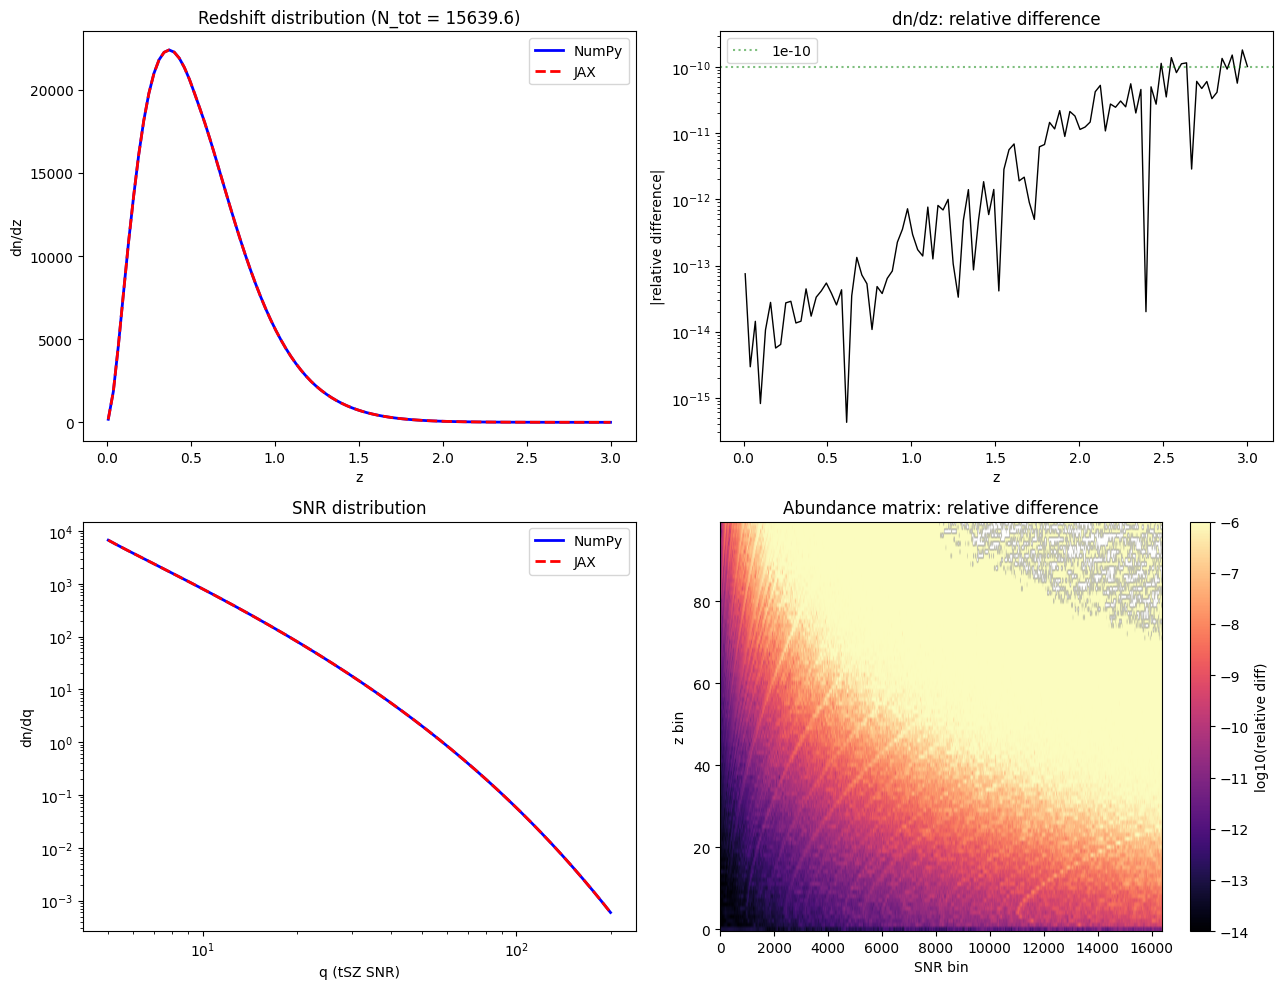

Saved: comparison_abundance.png


In [7]:
# ── N_tot ──
n_tot_np = float(nc_np.n_tot)
n_tot_jax = float(np.asarray(nc_jax.n_tot))
print(f"N_tot:")
print(f"  NumPy: {n_tot_np:.4f}")
print(f"  JAX:   {n_tot_jax:.4f}")
print(f"  rel_diff: {abs(n_tot_np - n_tot_jax)/n_tot_np:.2e}")

# ── dn/dz ──
nz_np = np.asarray(nc_np.n_z)
nz_jax = np.asarray(nc_jax.n_z)
rel_nz = np.abs(nz_np - nz_jax) / np.maximum(np.abs(nz_np), 1e-30)
print(f"\ndn/dz: max_rel = {rel_nz.max():.2e}, mean_rel = {rel_nz.mean():.2e}")

# ── dn/dSNR ──
nobs_np = np.asarray(nc_np.n_obs)
nobs_jax = np.asarray(nc_jax.n_obs)
obs_vec_np = np.asarray(nc_np.obs_select_vec)
obs_vec_jax = np.asarray(nc_jax.obs_select_vec)
mask_obs = nobs_np > 1e-30
rel_nobs = np.abs(nobs_np[mask_obs] - nobs_jax[mask_obs]) / nobs_np[mask_obs]
print(f"dn/dSNR: max_rel = {rel_nobs.max():.2e}, mean_rel = {rel_nobs.mean():.2e}")

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Top left: dn/dz
ax = axes[0, 0]
ax.plot(z_vec, nz_np, 'b-', lw=2, label='NumPy')
ax.plot(z_vec, nz_jax, 'r--', lw=2, label='JAX')
ax.set_xlabel('z')
ax.set_ylabel('dn/dz')
ax.set_title(f'Redshift distribution (N_tot = {n_tot_np:.1f})')
ax.legend()

# Top right: dn/dz relative difference
ax = axes[0, 1]
ax.semilogy(z_vec, rel_nz, 'k-', lw=1)
ax.set_xlabel('z')
ax.set_ylabel('|relative difference|')
ax.set_title('dn/dz: relative difference')
ax.axhline(1e-10, color='green', ls=':', alpha=0.5, label='1e-10')
ax.legend()

# Bottom left: dn/dSNR
ax = axes[1, 0]
ax.loglog(obs_vec_np, nobs_np, 'b-', lw=2, label='NumPy')
ax.loglog(obs_vec_jax, nobs_jax, 'r--', lw=2, label='JAX')
ax.set_xlabel('q (tSZ SNR)')
ax.set_ylabel('dn/dq')
ax.set_title('SNR distribution')
ax.legend()

# Bottom right: Abundance matrix comparison
ax = axes[1, 1]
abund_np = np.asarray(nc_np.abundance_matrix)
abund_jax = np.asarray(nc_jax.abundance_matrix)
mask_ab = abund_np > 1e-30
rel_abund = np.zeros_like(abund_np)
rel_abund[mask_ab] = np.abs(abund_np[mask_ab] - abund_jax[mask_ab]) / abund_np[mask_ab]
rel_abund[~mask_ab] = np.nan
im = ax.imshow(np.log10(rel_abund + 1e-20), aspect='auto', origin='lower',
               vmin=-14, vmax=-6, cmap='magma')
plt.colorbar(im, ax=ax, label='log10(relative diff)')
ax.set_xlabel('SNR bin')
ax.set_ylabel('z bin')
ax.set_title('Abundance matrix: relative difference')

plt.tight_layout()
plt.savefig('comparison_abundance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison_abundance.png")

## 4. Cosmological Quantities

Angular diameter distance $D_A(z)$, Hubble parameter $E(z) = H(z)/H_0$, and comoving volume element. These feed into the HMF and scaling relations.

D_A(z): max_rel = 2.30e-15, mean_rel = 8.34e-17
E(z):   max_rel = 8.44e-16, mean_rel = 9.41e-17


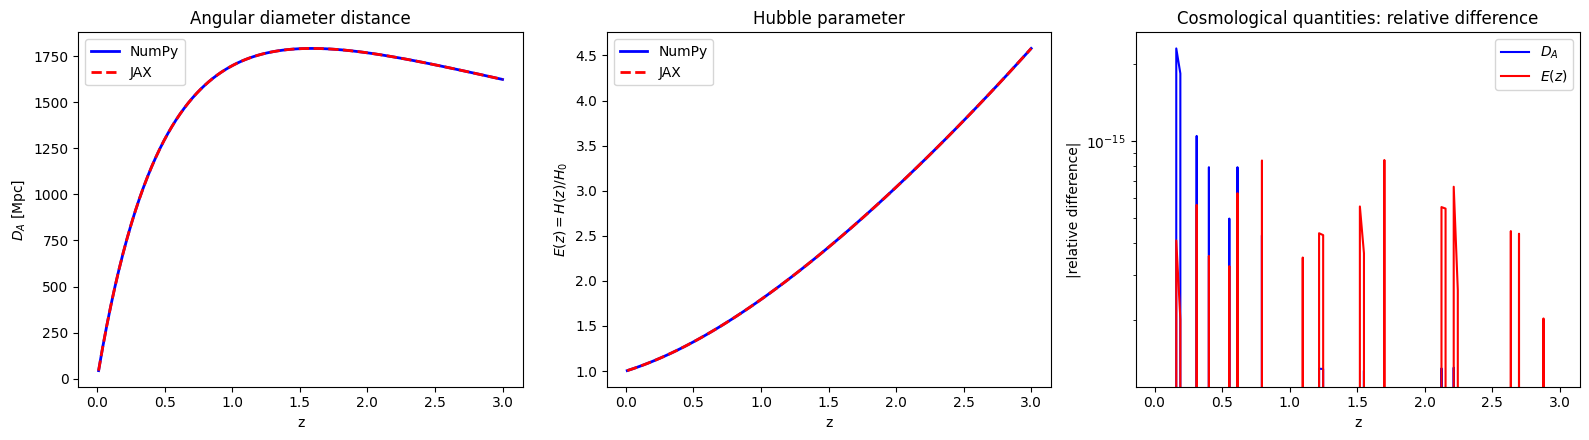

Saved: comparison_cosmo.png


In [8]:
DA_np = np.asarray(nc_np.D_A)
DA_jax = np.asarray(nc_jax.D_A)
Ez_np = np.asarray(nc_np.E_z)
Ez_jax = np.asarray(nc_jax.E_z)

rel_DA = np.abs(DA_np - DA_jax) / np.maximum(np.abs(DA_np), 1e-30)
rel_Ez = np.abs(Ez_np - Ez_jax) / np.maximum(np.abs(Ez_np), 1e-30)

print(f"D_A(z): max_rel = {rel_DA.max():.2e}, mean_rel = {rel_DA.mean():.2e}")
print(f"E(z):   max_rel = {rel_Ez.max():.2e}, mean_rel = {rel_Ez.mean():.2e}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# D_A
ax = axes[0]
ax.plot(z_vec, DA_np, 'b-', lw=2, label='NumPy')
ax.plot(z_vec, DA_jax, 'r--', lw=2, label='JAX')
ax.set_xlabel('z'); ax.set_ylabel('$D_A$ [Mpc]')
ax.set_title('Angular diameter distance')
ax.legend()

# E(z)
ax = axes[1]
ax.plot(z_vec, Ez_np, 'b-', lw=2, label='NumPy')
ax.plot(z_vec, Ez_jax, 'r--', lw=2, label='JAX')
ax.set_xlabel('z'); ax.set_ylabel('$E(z) = H(z)/H_0$')
ax.set_title('Hubble parameter')
ax.legend()

# Relative differences
ax = axes[2]
ax.semilogy(z_vec, rel_DA, 'b-', lw=1.5, label='$D_A$')
ax.semilogy(z_vec, rel_Ez, 'r-', lw=1.5, label='$E(z)$')
ax.set_xlabel('z'); ax.set_ylabel('|relative difference|')
ax.set_title('Cosmological quantities: relative difference')
ax.legend()

plt.tight_layout()
plt.savefig('comparison_cosmo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison_cosmo.png")

## 5. Binned Likelihood

The binned likelihood uses 2D bins in (z, SNR) space. The theory prediction $n_\mathrm{binned}$ is compared to the observed counts via a Poisson likelihood.

Binned log-likelihood:
  NumPy: 106280.939536
  JAX:   106280.933657
  rel_diff: 5.53e-08
  Timing: NumPy=0.0942s, JAX=4.9270s

Binned total counts:
  Theory NumPy: 15628.6 +/- 125.0
  Theory JAX:   15628.1 +/- 125.0
  Observed:     15798

n_binned agreement: max_rel = 1.78e-01, mean_rel = 3.99e-03


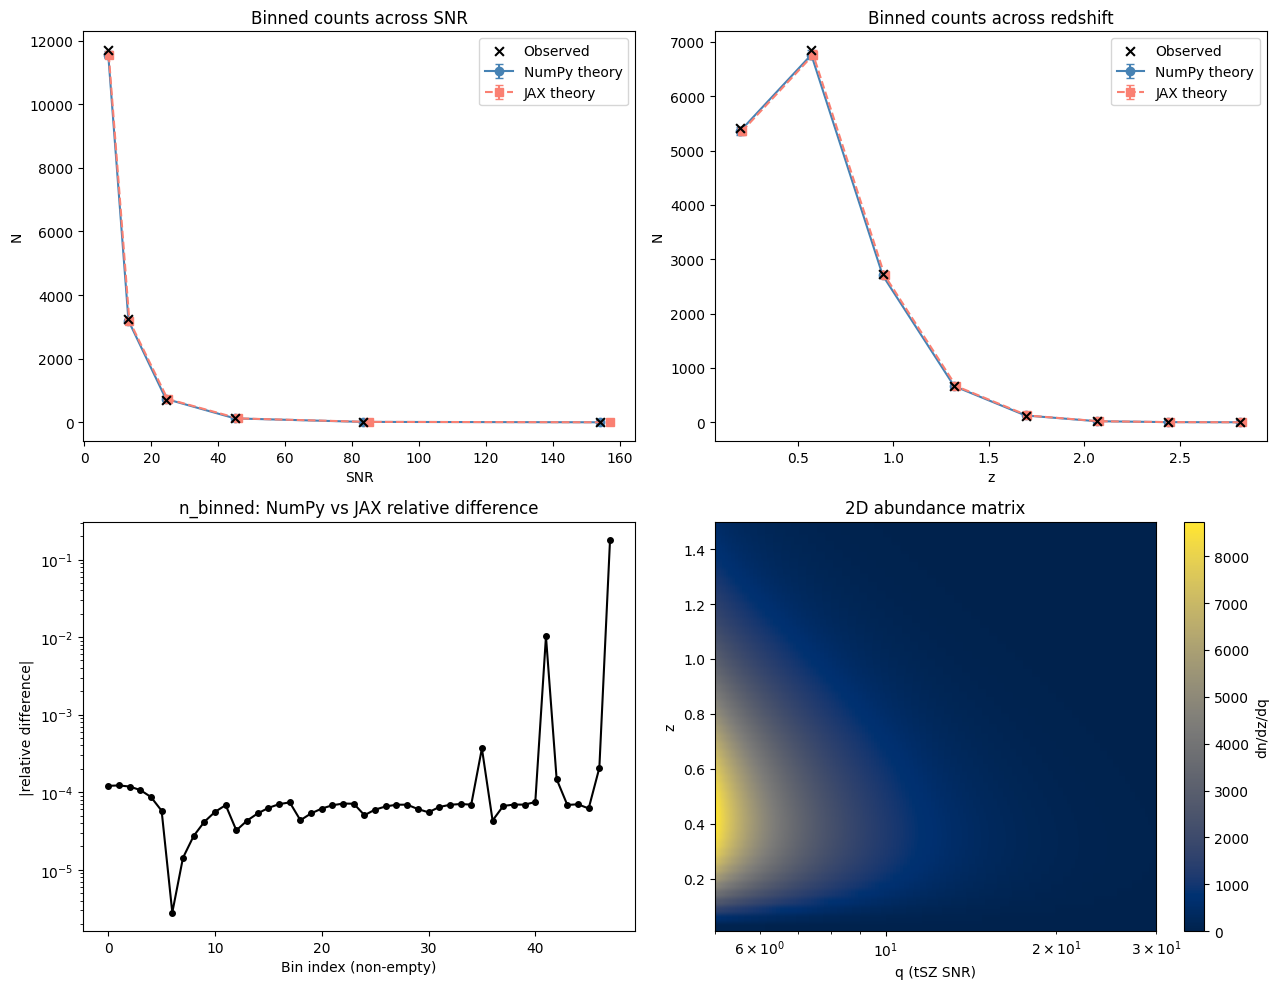

Saved: comparison_binned.png


In [9]:
# Switch to binned likelihood
nc_np.cnc_params["likelihood_type"] = "binned"
nc_np.cnc_params["data_lik_from_abundance"] = True
nc_np.cnc_params["observables"] = [["q_so_sim"]]
nc_jax.cnc_params["likelihood_type"] = "binned"
nc_jax.cnc_params["data_lik_from_abundance"] = True
nc_jax.cnc_params["observables"] = [["q_so_sim"]]

t0 = time.time()
ll_binned_np = nc_np.get_log_lik()
timings["binned_np"] = time.time() - t0

t0 = time.time()
ll_binned_jax = nc_jax.get_log_lik()
timings["binned_jax"] = time.time() - t0

ll_binned_np_val = float(ll_binned_np)
ll_binned_jax_val = float(np.asarray(ll_binned_jax))
rel_binned = abs(ll_binned_np_val - ll_binned_jax_val) / abs(ll_binned_np_val)

print(f"Binned log-likelihood:")
print(f"  NumPy: {ll_binned_np_val:.6f}")
print(f"  JAX:   {ll_binned_jax_val:.6f}")
print(f"  rel_diff: {rel_binned:.2e}")
print(f"  Timing: NumPy={timings['binned_np']:.4f}s, JAX={timings['binned_jax']:.4f}s")

# ── Binned counts: theory vs observed (as in tutorial) ──
nb_theory_np = np.asarray(nc_np.n_binned)
nb_theory_jax = np.asarray(nc_jax.n_binned)
nb_obs_np = np.asarray(nc_np.n_binned_obs)

# Marginalise over z and SNR
bins_z_np = nc_np.bins_centres_z
bins_snr_np = nc_np.bins_centres_obs

n_z_theory_np = np.sum(nb_theory_np, axis=1)
n_z_theory_jax = np.sum(nb_theory_jax, axis=1)
n_z_obs = np.sum(nb_obs_np, axis=1)

n_snr_theory_np = np.sum(nb_theory_np, axis=0)
n_snr_theory_jax = np.sum(nb_theory_jax, axis=0)
n_snr_obs = np.sum(nb_obs_np, axis=0)

n_tot_bins_np = np.sum(nb_theory_np)
n_tot_bins_jax = np.sum(nb_theory_jax)
n_tot_bins_obs = np.sum(nb_obs_np)

print(f"\nBinned total counts:")
print(f"  Theory NumPy: {n_tot_bins_np:.1f} +/- {np.sqrt(n_tot_bins_np):.1f}")
print(f"  Theory JAX:   {n_tot_bins_jax:.1f} +/- {np.sqrt(n_tot_bins_jax):.1f}")
print(f"  Observed:     {n_tot_bins_obs:.0f}")

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Top left: binned counts across SNR (theory vs observed)
ax = axes[0, 0]
ax.errorbar(bins_snr_np, n_snr_theory_np, yerr=np.sqrt(n_snr_theory_np),
            fmt='o-', color='steelblue', capsize=3, label='NumPy theory')
ax.errorbar(bins_snr_np * 1.02, n_snr_theory_jax, yerr=np.sqrt(n_snr_theory_jax),
            fmt='s--', color='salmon', capsize=3, label='JAX theory')
ax.scatter(bins_snr_np, n_snr_obs, color='k', marker='x', s=40, zorder=5, label='Observed')
ax.set_xlabel('SNR')
ax.set_ylabel('N')
ax.set_title('Binned counts across SNR')
ax.legend()

# Top right: binned counts across z
ax = axes[0, 1]
ax.errorbar(bins_z_np, n_z_theory_np, yerr=np.sqrt(n_z_theory_np),
            fmt='o-', color='steelblue', capsize=3, label='NumPy theory')
ax.errorbar(bins_z_np + 0.01, n_z_theory_jax, yerr=np.sqrt(n_z_theory_jax),
            fmt='s--', color='salmon', capsize=3, label='JAX theory')
ax.scatter(bins_z_np, n_z_obs, color='k', marker='x', s=40, zorder=5, label='Observed')
ax.set_xlabel('z')
ax.set_ylabel('N')
ax.set_title('Binned counts across redshift')
ax.legend()

# Bottom left: n_binned relative difference (NumPy vs JAX)
ax = axes[1, 0]
nb_flat_np = nb_theory_np.ravel()
nb_flat_jax = nb_theory_jax.ravel()
mask_nb = nb_flat_np > 1e-10
rel_nb = np.abs(nb_flat_np[mask_nb] - nb_flat_jax[mask_nb]) / nb_flat_np[mask_nb]
ax.semilogy(np.arange(len(rel_nb)), rel_nb, 'ko-', ms=4)
ax.set_xlabel('Bin index (non-empty)')
ax.set_ylabel('|relative difference|')
ax.set_title('n_binned: NumPy vs JAX relative difference')
print(f"\nn_binned agreement: max_rel = {rel_nb.max():.2e}, mean_rel = {rel_nb.mean():.2e}")

# Bottom right: 2D abundance matrix (as in tutorial)
ax = axes[1, 1]
abund_np = np.asarray(nc_np.abundance_matrix)
im = ax.imshow(np.flip(abund_np, axis=0), aspect='auto', cmap='cividis',
               extent=[obs_vec_np[0], obs_vec_np[-1], z_vec[0], z_vec[-1]])
plt.colorbar(im, ax=ax, label='dn/dz/dq')
ax.set_xscale('log')
ax.set_xlabel('q (tSZ SNR)')
ax.set_ylabel('z')
ax.set_xlim([5., 30.])
ax.set_ylim([0.01, 1.5])
ax.set_title('2D abundance matrix')

plt.tight_layout()
plt.savefig('comparison_binned.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison_binned.png")

## 6. Unbinned Likelihood (from abundance)

The unbinned likelihood with `data_lik_from_abundance=True` computes per-cluster likelihoods by interpolating the abundance tensor. This avoids the backward convolution.

In [10]:
# Switch to unbinned from abundance
nc_np.cnc_params["likelihood_type"] = "unbinned"
nc_np.cnc_params["data_lik_from_abundance"] = True
nc_np.cnc_params["observables"] = [["q_so_sim"]]
nc_jax.cnc_params["likelihood_type"] = "unbinned"
nc_jax.cnc_params["data_lik_from_abundance"] = True
nc_jax.cnc_params["observables"] = [["q_so_sim"]]

t0 = time.time()
ll_fa_np = nc_np.get_log_lik()
timings["unbinned_fa_np"] = time.time() - t0

t0 = time.time()
ll_fa_jax = nc_jax.get_log_lik()
timings["unbinned_fa_jax"] = time.time() - t0

ll_fa_np_val = float(ll_fa_np)
ll_fa_jax_val = float(np.asarray(ll_fa_jax))
rel_fa = abs(ll_fa_np_val - ll_fa_jax_val) / abs(ll_fa_np_val)

print(f"Unbinned log-likelihood (from abundance):")
print(f"  NumPy: {ll_fa_np_val:.6f}")
print(f"  JAX:   {ll_fa_jax_val:.6f}")
print(f"  rel_diff: {rel_fa:.2e}")
print(f"  Timing: NumPy={timings['unbinned_fa_np']:.4f}s, JAX={timings['unbinned_fa_jax']:.4f}s")

Unbinned log-likelihood (from abundance):
  NumPy: 76879.117453
  JAX:   76872.934184
  rel_diff: 8.04e-05
  Timing: NumPy=6.0887s, JAX=3.2244s


## 7. Unbinned Likelihood (backward convolutional)

The backward convolutional approach is the main likelihood evaluation method. It integrates over the mass function weighted by per-cluster conditional probability densities for each observable. This requires re-initialisation with `observables=[["q_so_sim"], ["p_so_sim"]]` and `data_lik_from_abundance=False`.

**Note**: JAX uses analytical scaling relation derivatives for mass range estimation (more accurate than NumPy's `np.gradient`), which causes a small expected difference.

In [11]:
# Re-initialise with backward conv settings
print("Initialising for backward convolutional...")

bc_params = {
    "observables": [["q_so_sim"], ["p_so_sim"]],
    "data_lik_from_abundance": False,
    "stacked_likelihood": False,
}

nc_np_bc = setup(cosmocnc, bc_params)
nc_jax_bc = setup(cosmocnc_jax, bc_params)

print("Computing number counts...")
nc_np_bc.get_number_counts()
nc_jax_bc.get_number_counts()

print("Computing backward conv likelihood...")
t0 = time.time()
ll_bc_np = nc_np_bc.get_log_lik()
timings["bc_np"] = time.time() - t0

t0 = time.time()
ll_bc_jax = nc_jax_bc.get_log_lik()
jax.block_until_ready(ll_bc_jax)
timings["bc_jax"] = time.time() - t0

ll_bc_np_val = float(ll_bc_np)
ll_bc_jax_val = float(np.asarray(ll_bc_jax))
rel_bc = abs(ll_bc_np_val - ll_bc_jax_val) / abs(ll_bc_np_val)

print(f"\nBackward conv log-likelihood:")
print(f"  NumPy: {ll_bc_np_val:.6f}")
print(f"  JAX:   {ll_bc_jax_val:.6f}")
print(f"  abs_diff: {abs(ll_bc_np_val - ll_bc_jax_val):.4f}")
print(f"  rel_diff: {rel_bc:.2e}")
print(f"  Timing: NumPy={timings['bc_np']:.4f}s, JAX={timings['bc_jax']:.4f}s")

Initialising for backward convolutional...


cosmo params {'Om0': 0.315, 'Ob0': 0.04897, 'Ob0h2': 0.022245895720000002, 'Oc0h2': 0.12085104428000001, 'h': 0.674, 'A_s': np.float64(2.0846720158043235e-09), 'n_s': 0.96, 'm_nu': 0.06, 'sigma_8': 0.8110000000000002, 'tau_reio': 0.0544, 'w0': -1.0, 'Onu0': 0.001418083698824921, 'N_eff': 3.046, 'k_cutoff': 100000000.0, 'ps_cutoff': 1}


cosmo params {'Om0': 0.315, 'Ob0': 0.04897, 'Ob0h2': 0.022245895720000002, 'Oc0h2': 0.12085104428000001, 'h': 0.674, 'A_s': np.float64(2.0846720158043235e-09), 'n_s': 0.96, 'm_nu': 0.06, 'sigma_8': 0.8110000000000002, 'tau_reio': 0.0544, 'w0': -1.0, 'Onu0': 0.001418083698824921, 'N_eff': 3.046, 'k_cutoff': 100000000.0, 'ps_cutoff': 1}
Computing number counts...


Total clusters: %.5f 15639.631922729868


Computing backward conv likelihood...



Backward conv log-likelihood:
  NumPy: 76879.117453
  JAX:   76872.934184
  abs_diff: 6.1833
  rel_diff: 8.04e-05
  Timing: NumPy=5.9552s, JAX=1.3923s


## 8. Stacked Likelihood

The stacked likelihood bins clusters by redshift and SNR, then compares the mean CMB lensing signal in each bin to the theoretical prediction.

In [12]:
# Re-initialise with stacked likelihood
# Following the tutorial: observables=[["q_so_sim"]], data_lik_from_abundance=False,
# stacked_likelihood=True, stacked_data=["p_so_sim_stacked"]
print("Initialising for stacked likelihood...")

st_params = {
    "observables": [["q_so_sim"]],
    "data_lik_from_abundance": False,
    "stacked_likelihood": True,
    "stacked_data": ["p_so_sim_stacked"],
    "compute_stacked_cov": True,
}

nc_np_st = setup(cosmocnc, st_params)
nc_jax_st = setup(cosmocnc_jax, st_params)

print("Computing number counts...")
nc_np_st.get_number_counts()
nc_jax_st.get_number_counts()

print("Computing stacked likelihood (unbinned + stacked)...")
t0 = time.time()
ll_st_np = nc_np_st.get_log_lik()
timings["stacked_np"] = time.time() - t0

t0 = time.time()
ll_st_jax = nc_jax_st.get_log_lik()
jax.block_until_ready(ll_st_jax)
timings["stacked_jax"] = time.time() - t0

ll_st_np_val = float(np.asarray(ll_st_np).ravel()[0])
ll_st_jax_val = float(np.asarray(ll_st_jax).ravel()[0])
rel_st = abs(ll_st_np_val - ll_st_jax_val) / max(abs(ll_st_np_val), 1e-30)

print(f"\nStacked log-likelihood (unbinned + stacked combined):")
print(f"  NumPy: {ll_st_np_val:.6f}")
print(f"  JAX:   {ll_st_jax_val:.6f}")
print(f"  rel_diff: {rel_st:.2e}")
print(f"  Timing: NumPy={timings['stacked_np']:.4f}s, JAX={timings['stacked_jax']:.4f}s")

# Compare stacked model predictions and variance
print("\n  Stacked observable predictions:")
for key in ["p_so_sim_stacked"]:
    if hasattr(nc_np_st, 'stacked_model') and key in nc_np_st.stacked_model:
        sm_np = float(np.asarray(nc_np_st.stacked_model[key]).ravel()[0])
        sm_jax = float(np.asarray(nc_jax_st.stacked_model[key]).ravel()[0])
        rd = abs(sm_np - sm_jax) / max(abs(sm_np), 1e-30)
        print(f"    theory mean:  NumPy={sm_np:.6f}, JAX={sm_jax:.6f}, rel_diff={rd:.2e}")

    if hasattr(nc_np_st, 'stacked_variance') and key in nc_np_st.stacked_variance:
        sv_np = float(np.asarray(nc_np_st.stacked_variance[key]).ravel()[0])
        sv_jax = float(np.asarray(nc_jax_st.stacked_variance[key]).ravel()[0])
        rd = abs(sv_np - sv_jax) / max(abs(sv_np), 1e-30)
        print(f"    theory std:   NumPy={np.sqrt(sv_np):.6f}, JAX={np.sqrt(sv_jax):.6f}, rel_diff={rd:.2e}")

    # Observed value from catalogue
    if hasattr(nc_np_st, 'catalogue') and hasattr(nc_np_st.catalogue, 'stacked_data'):
        obs_val = nc_np_st.catalogue.stacked_data[key]["data_vec"]
        print(f"    observed:     {float(np.asarray(obs_val).ravel()[0]):.6f}")

Initialising for stacked likelihood...


cosmo params {'Om0': 0.315, 'Ob0': 0.04897, 'Ob0h2': 0.022245895720000002, 'Oc0h2': 0.12085104428000001, 'h': 0.674, 'A_s': np.float64(2.0846720158043235e-09), 'n_s': 0.96, 'm_nu': 0.06, 'sigma_8': 0.8110000000000002, 'tau_reio': 0.0544, 'w0': -1.0, 'Onu0': 0.001418083698824921, 'N_eff': 3.046, 'k_cutoff': 100000000.0, 'ps_cutoff': 1}


cosmo params {'Om0': 0.315, 'Ob0': 0.04897, 'Ob0h2': 0.022245895720000002, 'Oc0h2': 0.12085104428000001, 'h': 0.674, 'A_s': np.float64(2.0846720158043235e-09), 'n_s': 0.96, 'm_nu': 0.06, 'sigma_8': 0.8110000000000002, 'tau_reio': 0.0544, 'w0': -1.0, 'Onu0': 0.001418083698824921, 'N_eff': 3.046, 'k_cutoff': 100000000.0, 'ps_cutoff': 1}
Computing number counts...


Total clusters: %.5f 15639.631922729868


Computing stacked likelihood (unbinned + stacked)...



Stacked log-likelihood (unbinned + stacked combined):
  NumPy: 99004.116260
  JAX:   98993.731623
  rel_diff: 1.05e-04
  Timing: NumPy=22.5135s, JAX=4.7848s

  Stacked observable predictions:
    theory mean:  NumPy=0.041197, JAX=0.040218, rel_diff=2.37e-02
    theory std:   NumPy=0.007957, JAX=0.007956, rel_diff=1.19e-04
    observed:     0.298620


## 9. Extreme Value Statistics & Goodness of Fit

Extreme value statistics predict the distribution of the maximum SNR cluster. The C statistic provides a goodness-of-fit measure for the binned model.

In [13]:
# Use the original nc_np/nc_jax (single observable, already computed number counts)

# ── Extreme value statistics ──
print("Extreme value statistics (most extreme cluster):")
nc_np.cnc_params["likelihood_type"] = "unbinned"
nc_jax.cnc_params["likelihood_type"] = "unbinned"

nc_np.get_log_lik_extreme_value()
nc_np.eval_extreme_value_quantities()
nc_jax.get_log_lik_extreme_value()
nc_jax.eval_extreme_value_quantities()

ev_max_mean_np = float(nc_np.obs_select_max_mean)
ev_max_mean_jax = float(np.asarray(nc_jax.obs_select_max_mean))
ev_max_std_np = float(nc_np.obs_select_max_std)
ev_max_std_jax = float(np.asarray(nc_jax.obs_select_max_std))
snr_max_obs = float(np.max(np.asarray(nc_np.catalogue.catalogue["q_so_sim"])))

rel_ev_mean = abs(ev_max_mean_np - ev_max_mean_jax) / abs(ev_max_mean_np)
rel_ev_std = abs(ev_max_std_np - ev_max_std_jax) / abs(ev_max_std_np)

print(f"  Predicted max SNR (NumPy): {ev_max_mean_np:.2f} +/- {ev_max_std_np:.2f}")
print(f"  Predicted max SNR (JAX):   {ev_max_mean_jax:.2f} +/- {ev_max_std_jax:.2f}")
print(f"  Observed max SNR:          {snr_max_obs:.2f}")
print(f"  rel_diff mean: {rel_ev_mean:.2e}, std: {rel_ev_std:.2e}")

# ── Goodness of fit (C statistic) ──
print("\nGoodness of fit (C statistic):")
nc_np.cnc_params["likelihood_type"] = "binned"
nc_np.cnc_params["data_lik_from_abundance"] = True
nc_jax.cnc_params["likelihood_type"] = "binned"
nc_jax.cnc_params["data_lik_from_abundance"] = True
nc_np.get_log_lik()
nc_jax.get_log_lik()

C_np, C_mean_np, C_std_np = nc_np.get_c_statistic()
C_jax, C_mean_jax, C_std_jax = nc_jax.get_c_statistic()

C_np, C_mean_np, C_std_np = float(C_np), float(C_mean_np), float(C_std_np)
C_jax, C_mean_jax, C_std_jax = float(np.asarray(C_jax)), float(np.asarray(C_mean_jax)), float(np.asarray(C_std_jax))

print(f"  Predicted C (NumPy): {C_mean_np:.2f} +/- {C_std_np:.2f}")
print(f"  Predicted C (JAX):   {C_mean_jax:.2f} +/- {C_std_jax:.2f}")
print(f"  Observed C (NumPy):  {C_np:.2f}")
print(f"  Observed C (JAX):    {C_jax:.2f}")
print(f"  C_observed rel_diff: {abs(C_np-C_jax)/abs(C_np):.2e}")
print(f"  C_mean rel_diff:     {abs(C_mean_np-C_mean_jax)/abs(C_mean_np):.2e}")

Extreme value statistics (most extreme cluster):


  Predicted max SNR (NumPy): 113.60 +/- 24.48
  Predicted max SNR (JAX):   113.60 +/- 24.48
  Observed max SNR:          94.86
  rel_diff mean: 1.43e-08, std: 1.02e-08

Goodness of fit (C statistic):


/scratch/scratch-izubeldia/cosmocnc/cosmocnc/utils.py:155: RuntimeWarning: divide by zero encountered in log
  return 2.*(n_mean - n_obs + n_obs*np.log(n_obs/n_mean))
/scratch/scratch-izubeldia/cosmocnc/cosmocnc/utils.py:155: RuntimeWarning: invalid value encountered in multiply
  return 2.*(n_mean - n_obs + n_obs*np.log(n_obs/n_mean))
/scratch/scratch-izubeldia/cosmocnc/cosmocnc/utils.py:189: RuntimeWarning: divide by zero encountered in log
  C_var = C_var + np.exp(-n_mean)*n_mean**j/math.factorial(j)*(n_mean-j+j*np.log(j/n_mean))**2
/scratch/scratch-izubeldia/cosmocnc/cosmocnc/utils.py:189: RuntimeWarning: invalid value encountered in scalar multiply
  C_var = C_var + np.exp(-n_mean)*n_mean**j/math.factorial(j)*(n_mean-j+j*np.log(j/n_mean))**2


  Predicted C (NumPy): 24.63 +/- 6.88
  Predicted C (JAX):   24.63 +/- 6.88
  Observed C (NumPy):  10.40
  Observed C (JAX):    10.41
  C_observed rel_diff: 1.09e-03
  C_mean rel_diff:     4.07e-07


## 9b. Cluster Mass Estimation

cosmocnc can estimate cluster masses from the backward convolutional approach. We compare the estimated masses and their uncertainties between both packages.

Initialising for mass estimation...


cosmo params {'Om0': 0.315, 'Ob0': 0.04897, 'Ob0h2': 0.022245895720000002, 'Oc0h2': 0.12085104428000001, 'h': 0.674, 'A_s': np.float64(2.0846720158043235e-09), 'n_s': 0.96, 'm_nu': 0.06, 'sigma_8': 0.8110000000000002, 'tau_reio': 0.0544, 'w0': -1.0, 'Onu0': 0.001418083698824921, 'N_eff': 3.046, 'k_cutoff': 100000000.0, 'ps_cutoff': 1}


cosmo params {'Om0': 0.315, 'Ob0': 0.04897, 'Ob0h2': 0.022245895720000002, 'Oc0h2': 0.12085104428000001, 'h': 0.674, 'A_s': np.float64(2.0846720158043235e-09), 'n_s': 0.96, 'm_nu': 0.06, 'sigma_8': 0.8110000000000002, 'tau_reio': 0.0544, 'w0': -1.0, 'Onu0': 0.001418083698824921, 'N_eff': 3.046, 'k_cutoff': 100000000.0, 'ps_cutoff': 1}
Computing number counts...


Total clusters: %.5f 15639.631922729868


Computing likelihood + masses (NumPy)...


Computing likelihood + masses (JAX)...



Mass estimation agreement:
  ln(M) mean: max_rel = 1.62e-01, mean_rel = 8.35e-04
  ln(M) std:  max_rel = 5.46e-01, mean_rel = 1.48e-02
  Timing: NumPy=6.56s, JAX=2.60s


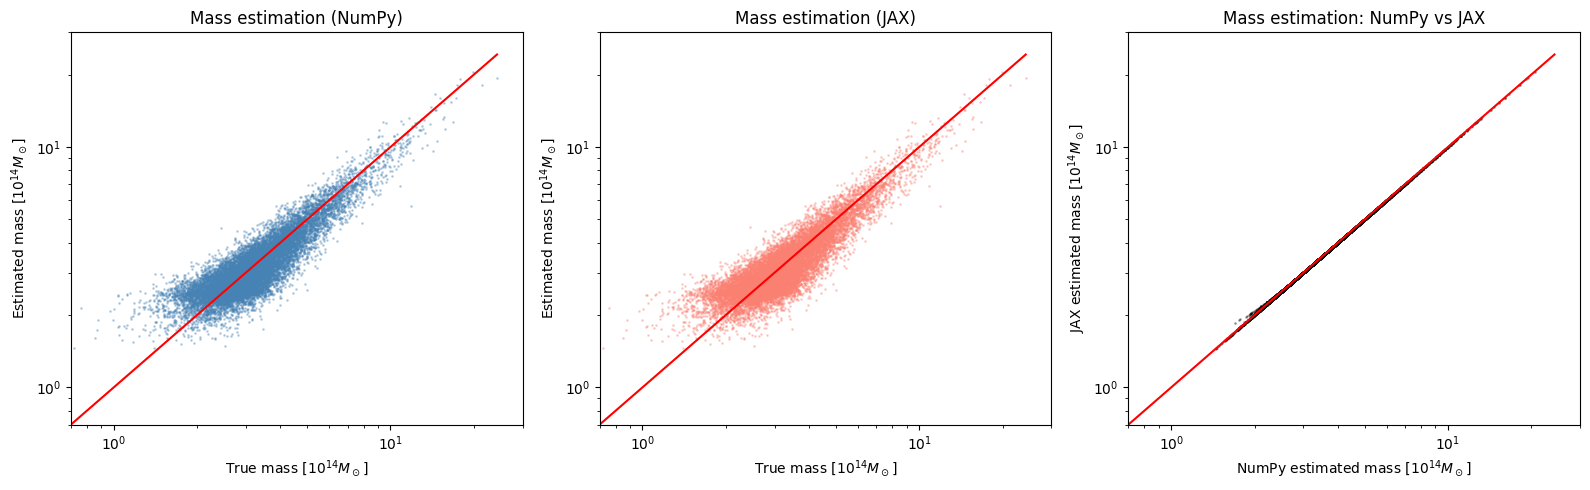

Saved: comparison_masses.png


In [14]:
# ── Cluster mass estimation ──
# Re-initialise with get_masses=True and single observable (as in tutorial)
print("Initialising for mass estimation...")

mass_params = {
    "observables": [["q_so_sim"]],
    "data_lik_from_abundance": False,
    "stacked_likelihood": False,
    "get_masses": True,
}

nc_np_mass = setup(cosmocnc, mass_params)
nc_jax_mass = setup(cosmocnc_jax, mass_params)

print("Computing number counts...")
nc_np_mass.get_number_counts()
nc_jax_mass.get_number_counts()

print("Computing likelihood + masses (NumPy)...")
t0 = time.time()
nc_np_mass.get_log_lik()
nc_np_mass.get_masses()
timings["mass_np"] = time.time() - t0

print("Computing likelihood + masses (JAX)...")
t0 = time.time()
nc_jax_mass.get_log_lik()
jax.block_until_ready(nc_jax_mass.log_lik)
nc_jax_mass.get_masses()
timings["mass_jax"] = time.time() - t0

# Compare mass estimates
lnM_est_np = np.asarray(nc_np_mass.cluster_lnM)
lnM_est_jax = np.asarray(nc_jax_mass.cluster_lnM)
lnM_std_np = np.asarray(nc_np_mass.cluster_lnM_std)
lnM_std_jax = np.asarray(nc_jax_mass.cluster_lnM_std)

rel_lnM = np.abs(lnM_est_np - lnM_est_jax) / np.maximum(np.abs(lnM_est_np), 1e-30)
rel_lnM_std = np.abs(lnM_std_np - lnM_std_jax) / np.maximum(np.abs(lnM_std_np), 1e-30)

print(f"\nMass estimation agreement:")
print(f"  ln(M) mean: max_rel = {rel_lnM.max():.2e}, mean_rel = {rel_lnM.mean():.2e}")
print(f"  ln(M) std:  max_rel = {rel_lnM_std.max():.2e}, mean_rel = {rel_lnM_std.mean():.2e}")
print(f"  Timing: NumPy={timings['mass_np']:.2f}s, JAX={timings['mass_jax']:.2f}s")

# True masses (available in simulated catalogue)
M_true = np.asarray(nc_np_mass.catalogue.M)  # in units of 1e14 M_sun
M_est_np = np.exp(lnM_est_np)  # also in 1e14 M_sun
M_est_jax = np.exp(lnM_est_jax)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: estimated vs true mass (NumPy, as in tutorial)
ax = axes[0]
ax.scatter(M_true, M_est_np, s=1, alpha=0.3, c='steelblue')
x = np.linspace(np.min(M_true), np.max(M_true), 100)
ax.plot(x, x, 'r-', lw=1.5)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim([0.7, 30.]); ax.set_ylim([0.7, 30.])
ax.set_xlabel('True mass [$10^{14} M_\\odot$]')
ax.set_ylabel('Estimated mass [$10^{14} M_\\odot$]')
ax.set_title('Mass estimation (NumPy)')

# Middle: estimated vs true mass (JAX)
ax = axes[1]
ax.scatter(M_true, M_est_jax, s=1, alpha=0.3, c='salmon')
ax.plot(x, x, 'r-', lw=1.5)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim([0.7, 30.]); ax.set_ylim([0.7, 30.])
ax.set_xlabel('True mass [$10^{14} M_\\odot$]')
ax.set_ylabel('Estimated mass [$10^{14} M_\\odot$]')
ax.set_title('Mass estimation (JAX)')

# Right: NumPy vs JAX mass estimates
ax = axes[2]
ax.scatter(M_est_np, M_est_jax, s=1, alpha=0.3, c='k')
ax.plot(x, x, 'r-', lw=1.5)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim([0.7, 30.]); ax.set_ylim([0.7, 30.])
ax.set_xlabel('NumPy estimated mass [$10^{14} M_\\odot$]')
ax.set_ylabel('JAX estimated mass [$10^{14} M_\\odot$]')
ax.set_title('Mass estimation: NumPy vs JAX')

plt.tight_layout()
plt.savefig('comparison_masses.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison_masses.png")

## 10. Parameter Scan (likelihood curves)

The most important test: varying $\sigma_8$ and comparing the full likelihood curve. Both the absolute log-likelihood values and the normalised likelihood shape must agree.

In [15]:
# ── Parameter scan over sigma_8 ──
# Use backward conv objects for the most comprehensive test
n_eval = 10
sigma_8_vec = np.linspace(0.800, 0.825, n_eval)

ll_scan_np = np.zeros(n_eval)
ll_scan_jax = np.zeros(n_eval)

print(f"Scanning sigma_8 in [{sigma_8_vec[0]:.3f}, {sigma_8_vec[-1]:.3f}] ({n_eval} points)...")

# NumPy scan
t0 = time.time()
for i in range(n_eval):
    cp = dict(nc_np_bc.cosmo_params)
    cp["sigma_8"] = sigma_8_vec[i]
    nc_np_bc.update_params(cp, dict(nc_np_bc.scal_rel_params))
    ll_scan_np[i] = nc_np_bc.get_log_lik()
timings["scan_bc_np"] = time.time() - t0

# JAX scan
t0 = time.time()
for i in range(n_eval):
    cp = dict(nc_jax_bc.cosmo_params)
    cp["sigma_8"] = sigma_8_vec[i]
    nc_jax_bc.update_params(cp, dict(nc_jax_bc.scal_rel_params))
    ll_tmp = nc_jax_bc.get_log_lik()
    jax.block_until_ready(ll_tmp)
    ll_scan_jax[i] = float(np.asarray(ll_tmp))
timings["scan_bc_jax"] = time.time() - t0

# Metrics
ll_abs_diff = np.abs(ll_scan_np - ll_scan_jax)
ll_rel_diff = ll_abs_diff / np.maximum(np.abs(ll_scan_np), 1e-30)
lik_np = np.exp(ll_scan_np - np.max(ll_scan_np))
lik_jax = np.exp(ll_scan_jax - np.max(ll_scan_jax))
lik_rel_diff = np.abs(lik_np - lik_jax) / np.maximum(lik_np, 1e-30)

print(f"\nlog_lik scan:")
print(f"  max abs_diff: {ll_abs_diff.max():.4f}")
print(f"  max rel_diff: {ll_rel_diff.max():.2e}")
print(f"\nNormalised likelihood curve:")
print(f"  max rel_diff: {lik_rel_diff.max():.2e}")
print(f"  mean rel_diff: {lik_rel_diff.mean():.2e}")

print(f"\nPer-point detail:")
print(f"  {'sigma_8':>8s}  {'ll_np':>14s}  {'ll_jax':>14s}  {'abs_diff':>10s}  {'rel_diff':>10s}")
for i in range(n_eval):
    print(f"  {sigma_8_vec[i]:8.4f}  {ll_scan_np[i]:14.4f}  {ll_scan_jax[i]:14.4f}  {ll_abs_diff[i]:10.4f}  {ll_rel_diff[i]:10.2e}")

print(f"\nTiming: NumPy={timings['scan_bc_np']:.2f}s ({timings['scan_bc_np']/n_eval*1000:.0f}ms/eval)")
print(f"        JAX  ={timings['scan_bc_jax']:.2f}s ({timings['scan_bc_jax']/n_eval*1000:.0f}ms/eval)")
print(f"        Speedup: {timings['scan_bc_np']/timings['scan_bc_jax']:.1f}x")

Scanning sigma_8 in [0.800, 0.825] (10 points)...


/scratch/scratch-izubeldia/cosmocnc/cosmocnc/cnc.py:144: DeprecationWarning: compute_class_szfast is deprecated. Use initialize_classy_szfast instead.
  self.cosmology.update_cosmology(cosmo_params,cosmology_tool=self.cnc_params["cosmology_tool"])


Total clusters: %.5f 13995.495670704233


Total clusters: %.5f 14398.234042984024


Total clusters: %.5f 14809.320856831253


...

Total clusters: %.5f 16993.300595764667


Total clusters: %.5f 17456.466256421496


Total clusters: %.5f 17928.640835655242


/scratch/scratch-izubeldia/cosmocnc_jax/cosmocnc_jax/cnc.py:706: DeprecationWarning: compute_class_szfast is deprecated. Use initialize_classy_szfast instead.
  self.cosmology.update_cosmology(cosmo_params,cosmology_tool=self.cnc_params["cosmology_tool"])



log_lik scan:
  max abs_diff: 6.6670
  max rel_diff: 8.69e-05

Normalised likelihood curve:
  max rel_diff: 3.88e-01
  mean rel_diff: 1.09e-01

Per-point detail:
   sigma_8           ll_np          ll_jax    abs_diff    rel_diff
    0.8000      76755.9641      76749.2972      6.6670    8.69e-05
    0.8028      76806.9648      76800.4259      6.5389    8.51e-05
    0.8056      76844.5348      76838.1198      6.4150    8.35e-05
    0.8083      76868.6496      76862.3547      6.2950    8.19e-05
    0.8111      76879.2837      76873.1050      6.1787    8.04e-05
    0.8139      76876.4105      76870.3445      6.0660    7.89e-05
    0.8167      76860.0028      76854.0461      5.9568    7.75e-05
    0.8194      76830.0324      76824.1816      5.8508    7.62e-05
    0.8222      76786.4704      76780.7223      5.7480    7.49e-05
    0.8250      76729.2868      76723.6385      5.6483    7.36e-05

Timing: NumPy=99.91s (9991ms/eval)
        JAX  =19.67s (1967ms/eval)
        Speedup: 5.1x


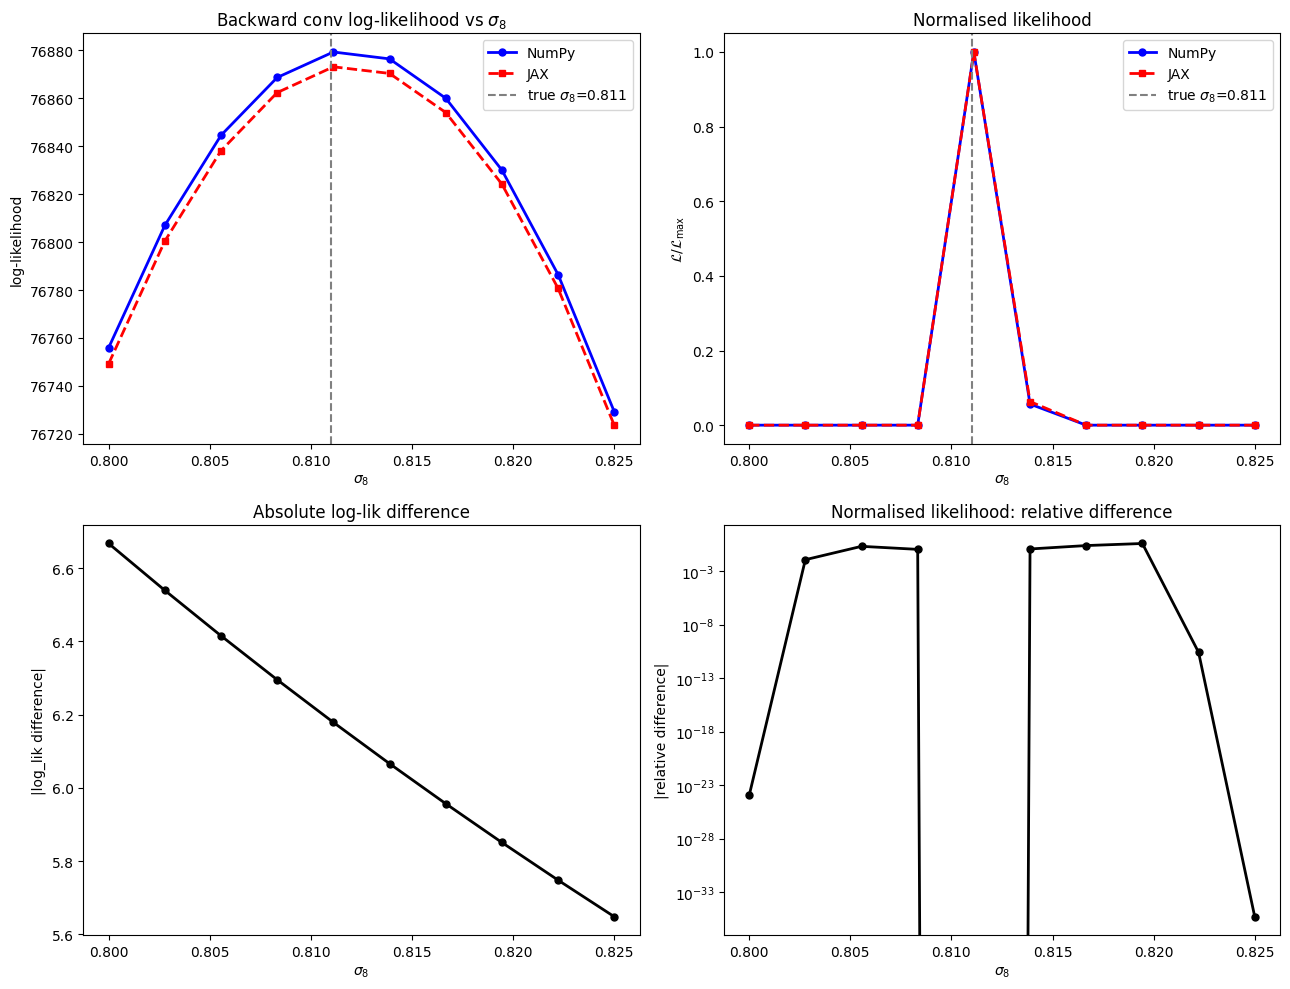

Saved: comparison_scan.png


In [16]:
# ── Plots for parameter scan ──
sigma_8_true = 0.811  # true value for SO_sim_0 catalogue

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Top left: log-likelihood curves
ax = axes[0, 0]
ax.plot(sigma_8_vec, ll_scan_np, 'b-o', lw=2, ms=5, label='NumPy')
ax.plot(sigma_8_vec, ll_scan_jax, 'r--s', lw=2, ms=5, label='JAX')
ax.axvline(sigma_8_true, color='gray', ls='--', lw=1.5, label=f'true $\\sigma_8$={sigma_8_true}')
ax.set_xlabel('$\\sigma_8$')
ax.set_ylabel('log-likelihood')
ax.set_title('Backward conv log-likelihood vs $\\sigma_8$')
ax.legend()

# Top right: normalised likelihood
ax = axes[0, 1]
ax.plot(sigma_8_vec, lik_np, 'b-o', lw=2, ms=5, label='NumPy')
ax.plot(sigma_8_vec, lik_jax, 'r--s', lw=2, ms=5, label='JAX')
ax.axvline(sigma_8_true, color='gray', ls='--', lw=1.5, label=f'true $\\sigma_8$={sigma_8_true}')
ax.set_xlabel('$\\sigma_8$')
ax.set_ylabel('$\\mathcal{L} / \\mathcal{L}_{\\max}$')
ax.set_title('Normalised likelihood')
ax.legend()

# Bottom left: absolute difference in log-lik
ax = axes[1, 0]
ax.plot(sigma_8_vec, ll_abs_diff, 'k-o', lw=2, ms=5)
ax.set_xlabel('$\\sigma_8$')
ax.set_ylabel('|log_lik difference|')
ax.set_title('Absolute log-lik difference')

# Bottom right: relative difference in normalised likelihood
ax = axes[1, 1]
ax.semilogy(sigma_8_vec, lik_rel_diff, 'k-o', lw=2, ms=5)
ax.set_xlabel('$\\sigma_8$')
ax.set_ylabel('|relative difference|')
ax.set_title('Normalised likelihood: relative difference')

plt.tight_layout()
plt.savefig('comparison_scan.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison_scan.png")

## 11. Summary

Collecting all results and timings into a final summary table.

NUMERICAL AGREEMENT SUMMARY
  n_points_data_lik = 256
  Both use classy_sz cosmology (same backend)

  [PASS] HMF matrix (max rel)                           5.82e-13
  [PASS] N_tot                                          7.40e-09
  [PASS] dn/dz (max rel)                                1.82e-10
  [PASS] dn/dSNR (max rel)                              4.43e-07
  [PASS] D_A(z) (max rel)                               2.30e-15
  [PASS] E(z) (max rel)                                 8.44e-16
  [PASS] Binned log-lik                                 5.53e-08
  [PASS] Unbinned log-lik (from abund.)                 8.04e-05
  [PASS] Backward conv log-lik                          8.04e-05
  [PASS] Stacked log-lik                                1.05e-04
  [PASS] Extreme value mean                             1.43e-08
  [WARN] C statistic                                    1.09e-03
  [FAIL] Mass est. ln(M) (max rel)                      1.62e-01
  [FAIL] Mass est. ln(M) std (max rel)                

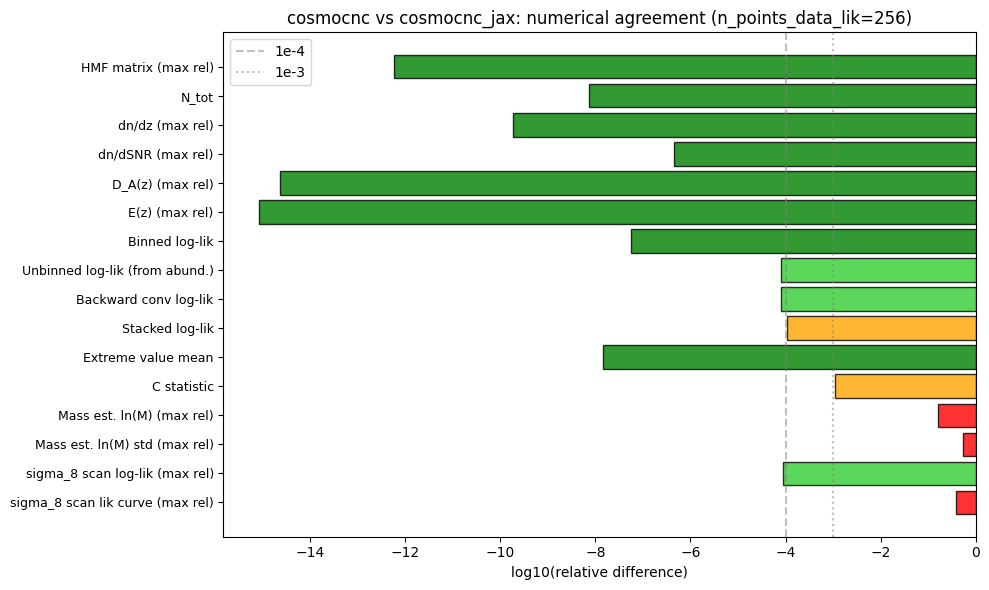


Saved: comparison_summary.png

All plots saved in tests/ directory.


In [17]:
# ── Final summary ──
print("=" * 80)
print("NUMERICAL AGREEMENT SUMMARY")
print("=" * 80)
print(f"  n_points_data_lik = 256")
print(f"  Both use classy_sz cosmology (same backend)")
print()

results = {
    "HMF matrix (max rel)": rel_diff_hmf.max(),
    "N_tot": abs(n_tot_np - n_tot_jax) / n_tot_np,
    "dn/dz (max rel)": rel_nz.max(),
    "dn/dSNR (max rel)": rel_nobs.max(),
    "D_A(z) (max rel)": rel_DA.max(),
    "E(z) (max rel)": rel_Ez.max(),
    "Binned log-lik": rel_binned,
    "Unbinned log-lik (from abund.)": rel_fa,
    "Backward conv log-lik": rel_bc,
    "Stacked log-lik": rel_st,
    "Extreme value mean": rel_ev_mean,
    "C statistic": abs(C_np - C_jax) / abs(C_np),
    "Mass est. ln(M) (max rel)": rel_lnM.max(),
    "Mass est. ln(M) std (max rel)": rel_lnM_std.max(),
    "sigma_8 scan log-lik (max rel)": ll_rel_diff.max(),
    "sigma_8 scan lik curve (max rel)": lik_rel_diff.max(),
}

for name, val in results.items():
    status = "PASS" if val < 1e-3 else ("WARN" if val < 1e-2 else "FAIL")
    print(f"  [{status}] {name:45s}  {val:.2e}")

print()
print("=" * 80)
print("TIMING SUMMARY")
print("=" * 80)

timing_pairs = [
    ("Init", "init_np", "init_jax"),
    ("Number counts", "nc_np", "nc_jax"),
    ("Binned likelihood", "binned_np", "binned_jax"),
    ("Unbinned (from abund.)", "unbinned_fa_np", "unbinned_fa_jax"),
    ("Backward conv likelihood", "bc_np", "bc_jax"),
    ("Stacked likelihood", "stacked_np", "stacked_jax"),
    ("Mass estimation", "mass_np", "mass_jax"),
]

print(f"  {'Test':30s}  {'NumPy':>10s}  {'JAX':>10s}  {'Speedup':>8s}")
print(f"  {'─'*30}  {'─'*10}  {'─'*10}  {'─'*8}")
for name, k_np, k_jax in timing_pairs:
    if k_np in timings and k_jax in timings:
        t_np = timings[k_np]
        t_jax = timings[k_jax]
        speedup = t_np / max(t_jax, 1e-10)
        print(f"  {name:30s}  {t_np:10.3f}s  {t_jax:10.3f}s  {speedup:7.1f}x")

if "scan_bc_np" in timings:
    t_np = timings["scan_bc_np"] / n_eval
    t_jax = timings["scan_bc_jax"] / n_eval
    speedup = t_np / max(t_jax, 1e-10)
    print(f"  {'BC scan (per eval)':30s}  {t_np:10.3f}s  {t_jax:10.3f}s  {speedup:7.1f}x")

# Summary plot
fig, ax = plt.subplots(figsize=(10, 6))
names = list(results.keys())
vals = list(results.values())
colors = ['green' if v < 1e-6 else 'limegreen' if v < 1e-4 else 'orange' if v < 1e-2 else 'red' for v in vals]
bars = ax.barh(range(len(names)), np.log10(np.array(vals) + 1e-20), color=colors, edgecolor='k', alpha=0.8)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel('log10(relative difference)')
ax.set_title('cosmocnc vs cosmocnc_jax: numerical agreement (n_points_data_lik=256)')
ax.axvline(-4, color='gray', ls='--', alpha=0.5, label='1e-4')
ax.axvline(-3, color='gray', ls=':', alpha=0.5, label='1e-3')
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('comparison_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: comparison_summary.png")
print("\nAll plots saved in tests/ directory.")